In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)

print("Kütüphaneler yüklendi ✓")

Kütüphaneler yüklendi ✓


In [2]:
# Veri setini lokal dosyadan oku
sutunlar = ["class", "age", "menopause", "tumor-size", "inv-nodes",
            "node-caps", "deg-malig", "breast", "breast-quad", "irradiat"]

df = pd.read_csv("breast-cancer.data", header=None, names=sutunlar, na_values="?")

print("Veri seti boyutu:", df.shape)
df.head()

Veri seti boyutu: (286, 10)


,class,age,menopause,tumor-size,inv-nodes,node-caps,deg-malig,breast,breast-quad,irradiat
0,no-recurrence-events,30-39,premeno,30-34,0-2,no,3,left,left_low,no
1,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,right,right_up,no
2,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,left,left_low,no
3,no-recurrence-events,60-69,ge40,15-19,0-2,no,2,right,left_up,no
4,no-recurrence-events,40-49,premeno,0-4,0-2,no,2,right,right_low,no


In [3]:
# Veri seti bilgileri
print("Sütun tipleri:")
print(df.dtypes)
print("\nEksik değerler:")
print(df.isnull().sum())
print("\nSınıf dağılımı:")
print(df["class"].value_counts())

Sütun tipleri:
class          object
age            object
menopause      object
tumor-size     object
inv-nodes      object
node-caps      object
deg-malig       int64
breast         object
breast-quad    object
irradiat       object
dtype: object

Eksik değerler:
class          0
age            0
menopause      0
tumor-size     0
inv-nodes      0
node-caps      8
deg-malig      0
breast         0
breast-quad    1
irradiat       0
dtype: int64

Sınıf dağılımı:
class
no-recurrence-events    201
recurrence-events        85
Name: count, dtype: int64


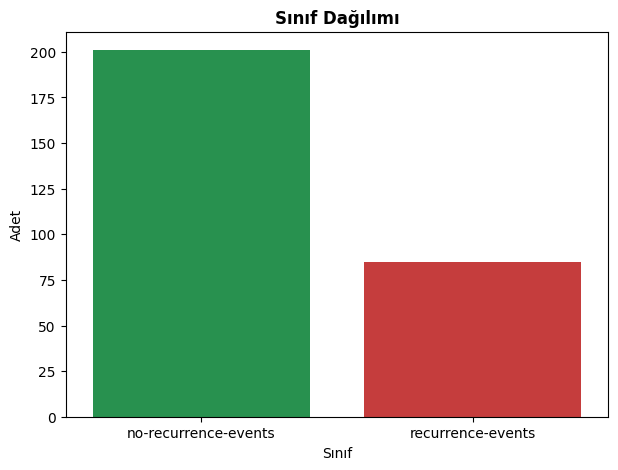

In [4]:
plt.figure(figsize=(7,5))
sns.countplot(x="class", data=df, palette=["#16a34a","#dc2626"])
plt.title("Sınıf Dağılımı", fontweight="bold")
plt.xlabel("Sınıf"); plt.ylabel("Adet")
plt.show()

In [5]:
for col in df.columns:
    if df[col].isnull().any():
        df[col].fillna(df[col].mode()[0], inplace=True)

print("Eksik değer kaldı mı:", df.isnull().sum().sum())

Eksik değer kaldı mı: 0


In [6]:
le = LabelEncoder()
df_enc = df.copy()
for col in df_enc.columns:
    df_enc[col] = le.fit_transform(df_enc[col].astype(str))

df_enc.head()

,class,age,menopause,tumor-size,inv-nodes,node-caps,deg-malig,breast,breast-quad,irradiat
0,0,1,2,5,0,0,2,0,1,0
1,0,2,2,3,0,0,1,1,4,0
2,0,2,2,3,0,0,1,0,1,0
3,0,4,0,2,0,0,1,1,2,0
4,0,2,2,0,0,0,1,1,3,0


In [7]:
X = df_enc.drop("class", axis=1)
y = df_enc["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print("Eğitim seti:", X_train.shape)
print("Test seti  :", X_test.shape)

Eğitim seti: (228, 9)
Test seti  : (58, 9)


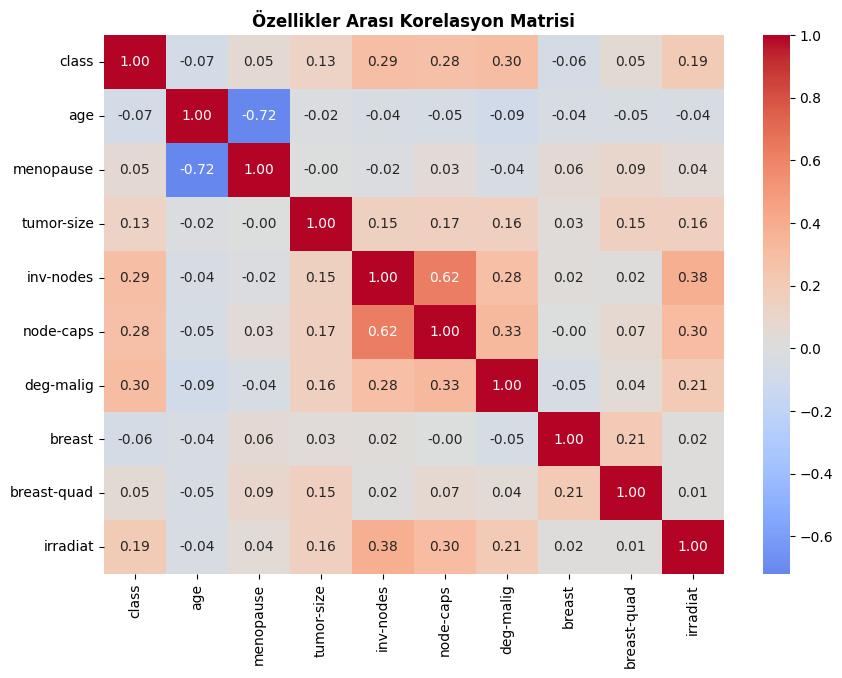

In [8]:
plt.figure(figsize=(10,7))
sns.heatmap(df_enc.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Özellikler Arası Korelasyon Matrisi", fontweight="bold")
plt.show()

In [9]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_pred_prob = rf.predict_proba(X_test)[:, 1]

print("Model eğitildi ✓")

Model eğitildi ✓


In [10]:
accuracy    = accuracy_score(y_test, y_pred)
precision   = precision_score(y_test, y_pred, zero_division=0)
recall      = recall_score(y_test, y_pred, zero_division=0)
f1          = f1_score(y_test, y_pred, zero_division=0)
roc_auc     = roc_auc_score(y_test, y_pred_prob)
cm          = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)

print(f"Accuracy    : {accuracy:.4f}")
print(f"Precision   : {precision:.4f}")
print(f"Sensitivity : {recall:.4f}")
print(f"Specificity : {specificity:.4f}")
print(f"F1-Score    : {f1:.4f}")
print(f"ROC-AUC     : {roc_auc:.4f}")

Accuracy    : 0.6897
Precision   : 0.4667
Sensitivity : 0.4118
Specificity : 0.8049
F1-Score    : 0.4375
ROC-AUC     : 0.5416


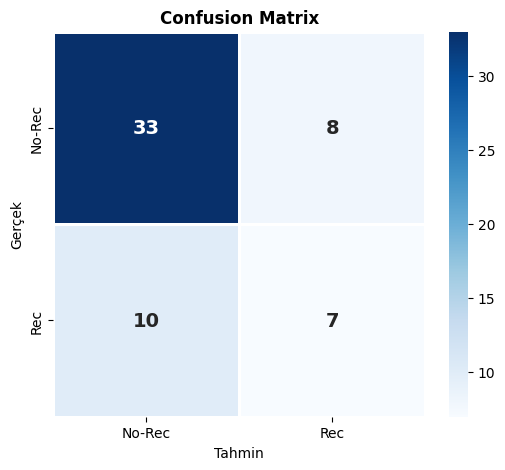

In [11]:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No-Rec","Rec"],
            yticklabels=["No-Rec","Rec"],
            annot_kws={"size":14,"weight":"bold"},
            linewidths=1, linecolor="white")
plt.title("Confusion Matrix", fontweight="bold")
plt.xlabel("Tahmin"); plt.ylabel("Gerçek")
plt.show()

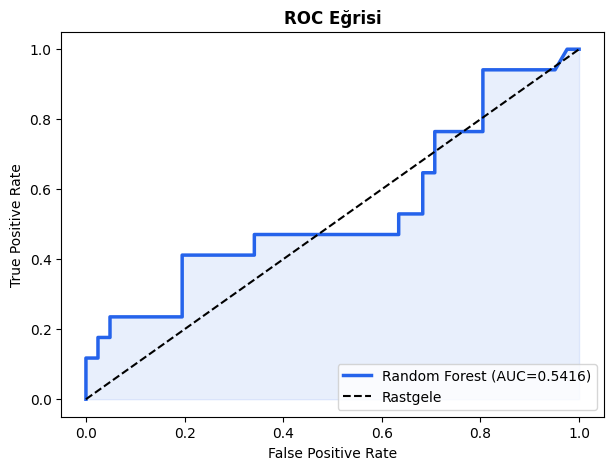

In [12]:
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color="#2563eb", lw=2.5, label=f"Random Forest (AUC={roc_auc:.4f})")
plt.plot([0,1],[0,1],"k--", lw=1.5, label="Rastgele")
plt.fill_between(fpr, tpr, alpha=0.1, color="#2563eb")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Eğrisi", fontweight="bold")
plt.legend(loc="lower right")
plt.show()

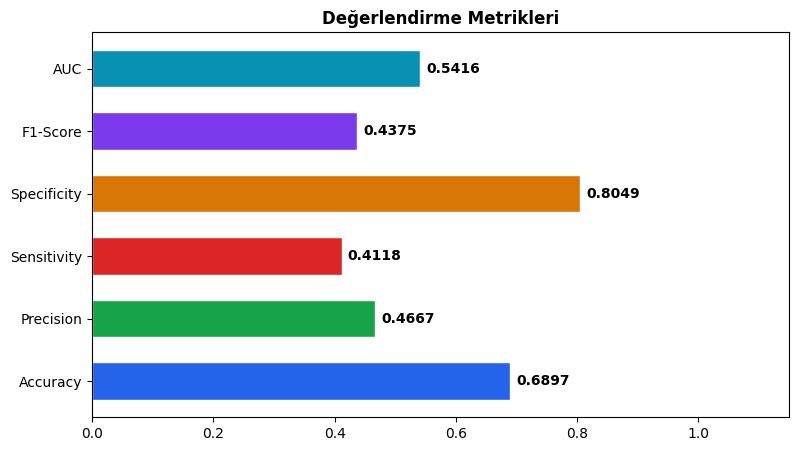

In [13]:
metrics = ["Accuracy","Precision","Sensitivity","Specificity","F1-Score","AUC"]
values  = [accuracy, precision, recall, specificity, f1, roc_auc]
colors  = ["#2563eb","#16a34a","#dc2626","#d97706","#7c3aed","#0891b2"]

plt.figure(figsize=(9,5))
bars = plt.barh(metrics, values, color=colors, edgecolor="white", height=0.6)
plt.xlim([0,1.15])
plt.title("Değerlendirme Metrikleri", fontweight="bold")
for bar, val in zip(bars, values):
    plt.text(val+0.01, bar.get_y()+bar.get_height()/2,
             f"{val:.4f}", va="center", fontsize=10, fontweight="bold")
plt.show()

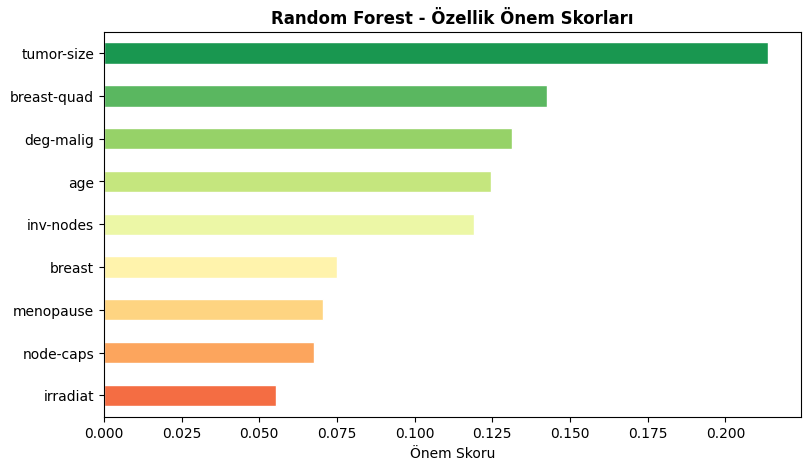

In [14]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
colors_imp = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(importances)))

plt.figure(figsize=(9,5))
importances.plot(kind="barh", color=colors_imp, edgecolor="white")
plt.title("Random Forest - Özellik Önem Skorları", fontweight="bold")
plt.xlabel("Önem Skoru")
plt.show()

In [15]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X, y, cv=cv, scoring="accuracy")

print(f"10-Katlı CV Ortalama: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
for i, s in enumerate(cv_scores, 1):
    print(f"  Kat {i:2d}: {s:.4f}")

10-Katlı CV Ortalama: 0.7039 ± 0.1017
  Kat  1: 0.7586
  Kat  2: 0.6552
  Kat  3: 0.7241
  Kat  4: 0.6552
  Kat  5: 0.4828
  Kat  6: 0.6207
  Kat  7: 0.8214
  Kat  8: 0.8571
  Kat  9: 0.7500
  Kat 10: 0.7143


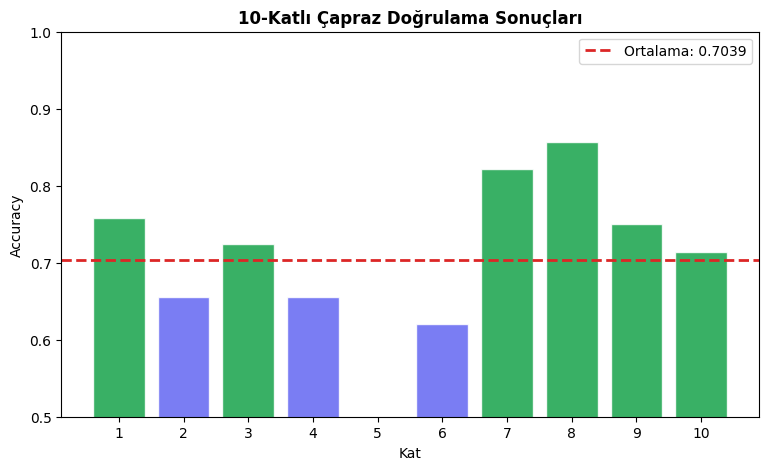

In [16]:
bar_colors = ["#16a34a" if s >= cv_scores.mean() else "#6366f1" for s in cv_scores]
plt.figure(figsize=(9,5))
plt.bar(range(1,11), cv_scores, color=bar_colors, edgecolor="white", alpha=0.85)
plt.axhline(cv_scores.mean(), color="#dc2626", linestyle="--", lw=2,
            label=f"Ortalama: {cv_scores.mean():.4f}")
plt.xticks(range(1,11))
plt.ylim([0.5, 1.0])
plt.xlabel("Kat"); plt.ylabel("Accuracy")
plt.title("10-Katlı Çapraz Doğrulama Sonuçları", fontweight="bold")
plt.legend()
plt.show()

In [17]:
from scipy import stats

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X, y, cv=cv, scoring="accuracy")

n = len(cv_scores)
mean = cv_scores.mean()
se = cv_scores.std(ddof=1) / np.sqrt(n)
t_crit = stats.t.ppf(0.975, df=n-1)

ci_lower = (mean - t_crit * se) * 100
ci_upper = (mean + t_crit * se) * 100

print("=" * 45)
print("   %95 GÜVENİLİRLİK ARALIĞI (10-Fold CV)")
print("=" * 45)
print(f"   Ortalama Accuracy : %{mean*100:.2f}")
print(f"   Güven Aralığı     : %{ci_lower:.1f}  –  %{ci_upper:.1f}")
print("=" * 45)


   %95 GÜVENİLİRLİK ARALIĞI (10-Fold CV)
   Ortalama Accuracy : %70.39
   Güven Aralığı     : %62.7  –  %78.1


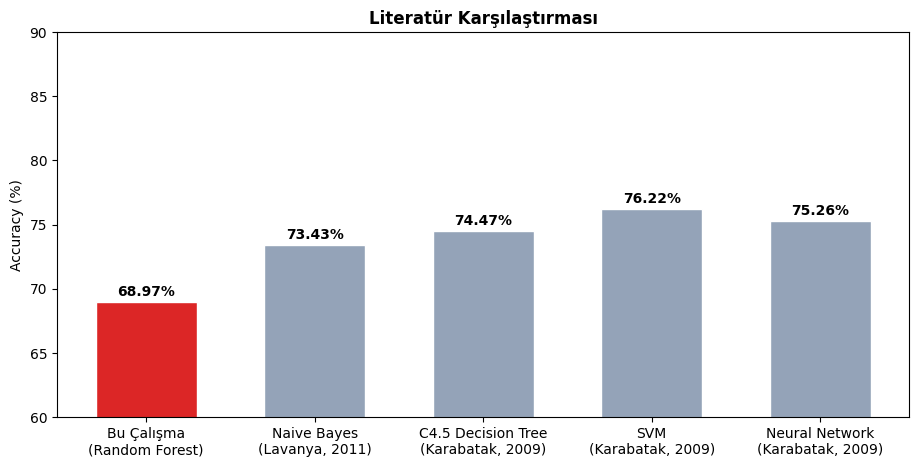

In [18]:
lit_methods = [
    "Bu Çalışma\n(Random Forest)",
    "Naive Bayes\n(Lavanya, 2011)",
    "C4.5 Decision Tree\n(Karabatak, 2009)",
    "SVM\n(Karabatak, 2009)",
    "Neural Network\n(Karabatak, 2009)"
]
lit_acc = [accuracy*100, 73.43, 74.47, 76.22, 75.26]
bar_colors2 = ["#dc2626"] + ["#94a3b8"]*4

plt.figure(figsize=(11,5))
bars2 = plt.bar(lit_methods, lit_acc, color=bar_colors2, edgecolor="white", width=0.6)
plt.ylim([60, 90])
plt.ylabel("Accuracy (%)")
plt.title("Literatür Karşılaştırması", fontweight="bold")
for bar, val in zip(bars2, lit_acc):
    plt.text(bar.get_x()+bar.get_width()/2, val+0.5,
             f"{val:.2f}%", ha="center", fontsize=10, fontweight="bold")
plt.show()

In [19]:
karsilastirma = pd.DataFrame({
    "Yöntem": [
        "Random Forest (Bu Çalışma)",
        "Naive Bayes (Lavanya & Usha Rani, 2011)",
        "C4.5 Decision Tree (Karabatak & Ince, 2009)",
        "SVM (Karabatak & Ince, 2009)",
        "Neural Network (Karabatak & Ince, 2009)"
    ],
    "Accuracy (%)": [f"{accuracy*100:.2f}", "73.43", "74.47", "76.22", "75.26"]
})
karsilastirma

,Yöntem,Accuracy (%)
0,Random Forest (Bu Çalışma),68.97
1,"Naive Bayes (Lavanya & Usha Rani, 2011)",73.43
2,"C4.5 Decision Tree (Karabatak & Ince, 2009)",74.47
3,"SVM (Karabatak & Ince, 2009)",76.22
4,"Neural Network (Karabatak & Ince, 2009)",75.26


In [20]:
# Örnek yeni hasta verisi (kategori değerlerinin sayısal karşılıkları)
# Bu hasta: 50-59 yaş, premeno, tümör 25-29, lenf düğümü yok vs.
yeni_hasta = pd.DataFrame([X_test.iloc[0]])  # Test setinden bir örnek alıyoruz

tahmin = rf.predict(yeni_hasta)[0]
olasilik = rf.predict_proba(yeni_hasta)[0]

print("=" * 50)
print("YENİ HASTA İÇİN TAHMİN")
print("=" * 50)
print(f"\nHasta özellikleri:")
print(yeni_hasta.T)
print(f"\nTahmin: {'RECURRENCE (Tekrarlayacak)' if tahmin == 1 else 'NO-RECURRENCE (Tekrarlamayacak)'}")
print(f"\nOlasılıklar:")
print(f"  No-Recurrence: {olasilik[0]*100:.2f}%")
print(f"  Recurrence   : {olasilik[1]*100:.2f}%")

YENİ HASTA İÇİN TAHMİN

Hasta özellikleri:
             74
age           1
menopause     2
tumor-size    9
inv-nodes     0
node-caps     0
deg-malig     1
breast        0
breast-quad   3
irradiat      0

Tahmin: NO-RECURRENCE (Tekrarlamayacak)

Olasılıklar:
  No-Recurrence: 84.00%
  Recurrence   : 16.00%


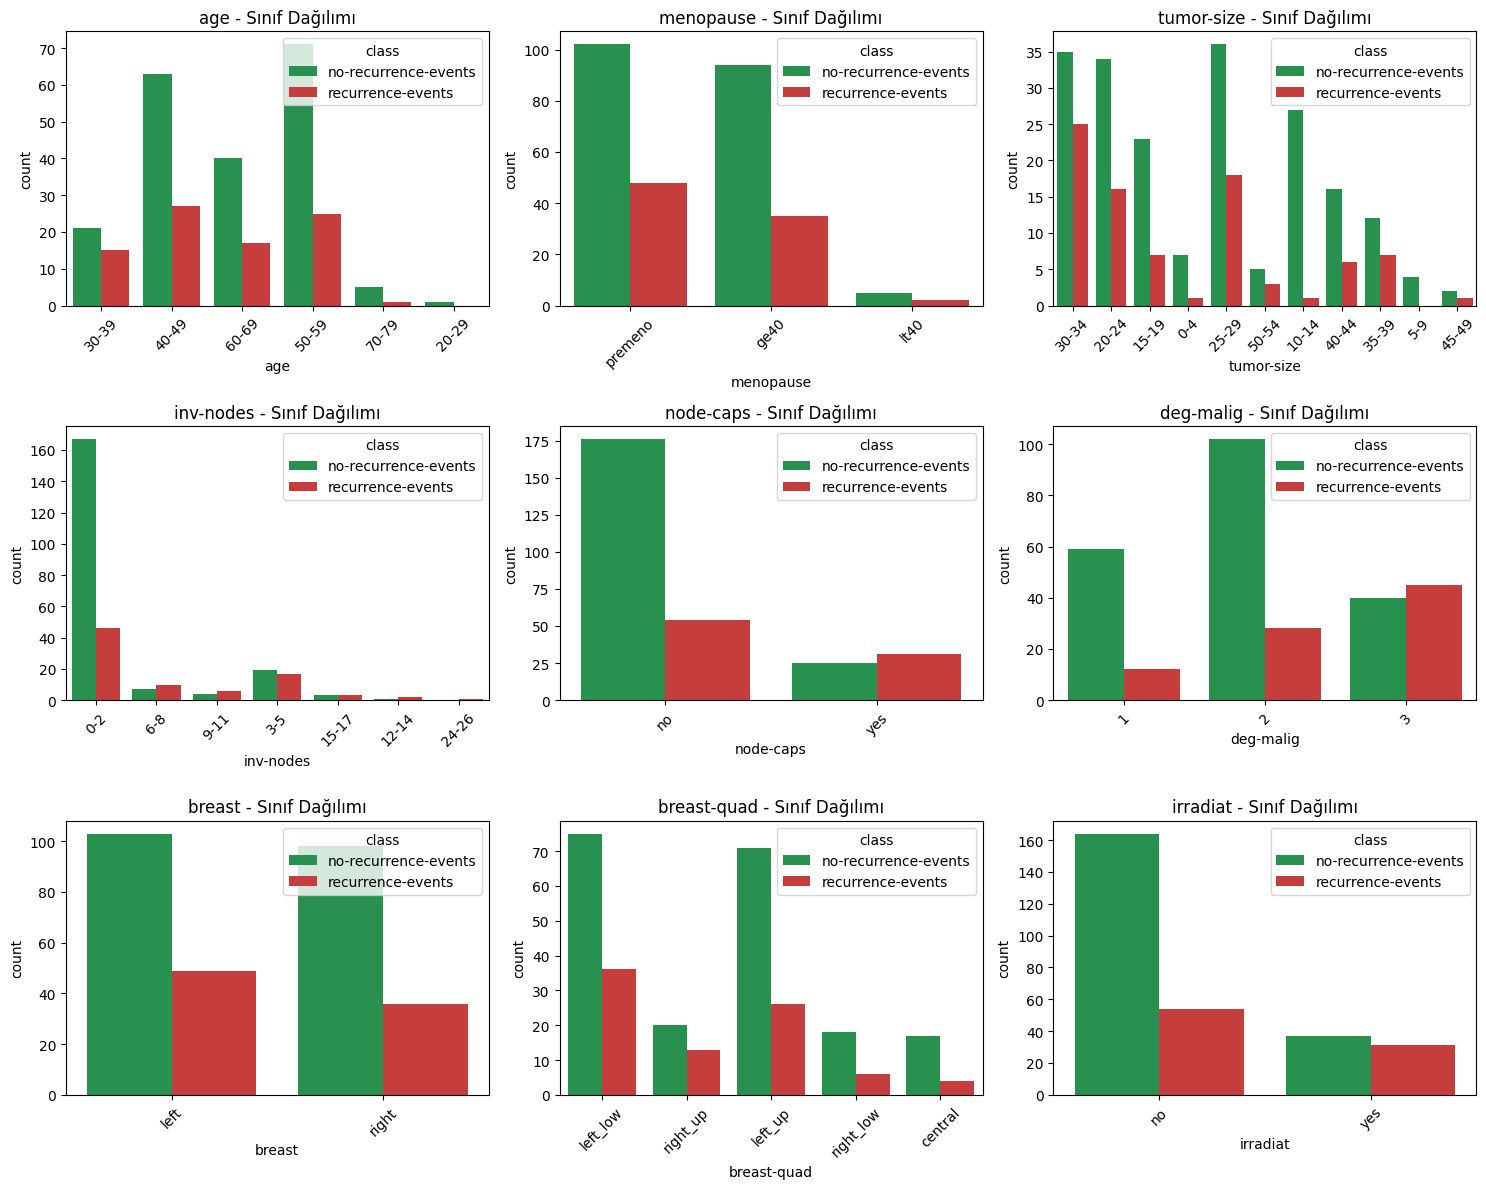

In [21]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for i, col in enumerate(df.columns[1:]):
    sns.countplot(x=col, hue="class", data=df, ax=axes[i//3, i%3], 
                  palette=["#16a34a","#dc2626"])
    axes[i//3, i%3].set_title(f"{col} - Sınıf Dağılımı")
    axes[i//3, i%3].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()